In [1]:
import re
import json
import shutil
import subprocess
from pathlib import Path
from pprint import pprint

import numpy as np
import pandas as pd

import torch
from sentence_transformers import SentenceTransformer

import faiss
from elasticsearch import Elasticsearch, helpers

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BASE_DIR  = Path.cwd()
IR_DIR    = BASE_DIR / "IR2025"
EMBED_DIR = BASE_DIR / "Embeddings"

DOCS_CSV    = IR_DIR / "documents.csv"
QUERIES_CSV = IR_DIR / "queries.csv"

DOCS_JSONL  = IR_DIR / "documents.jsonl"  # already exists in your IR2025
QRELS_CSV   = IR_DIR / "qrels.csv"
QRELS_TXT   = IR_DIR / "qrels.txt"

TREC_EVAL_BIN = IR_DIR / "trec_eval" / "trec_eval.exe"

# Embeddings: prefer the ones from Part B; fallback to *3.npy if you want to keep separate
DOC_EMBED_MAIN   = EMBED_DIR / "doc_embeddings.npy"
QUERY_EMBED_MAIN = EMBED_DIR / "query_embeddings.npy"
DOC_EMBED_FALL   = EMBED_DIR / "doc_embeddings3.npy"
QUERY_EMBED_FALL = EMBED_DIR / "query_embeddings3.npy"

# Output hybrid results
RESULT_KS = (20, 30, 50)
RUN_TAG   = "HYBRID"

# Hybrid hyperparams
TOP_N_CANDIDATES = 200          # N candidates from ES per query (N >> k)
FAISS_USE_COSINE = True         # normalize + inner product
RECREATE_INDEX   = False        # set True only if you want to delete+rebuild ES index

# Embedding params (only used if we need to generate embeddings)
DOC_BATCH   = 64
QUERY_BATCH = 32

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [4]:
def preprocess(s):
    if not isinstance(s, str):
        return ""
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"http\S+|www\.\S+", "<URL>", s)
    s = re.sub(r"\S+@\S+", "<EMAIL>", s)
    s = re.sub(r"<[^>]+>", " ", s)
    s = ''.join(ch for ch in s if ord(ch) >= 32)
    s = re.sub(r"['\"]", "", s)
    return s.strip()

In [5]:
def ensure_exists(p: Path, name="file"):
    if not p.exists():
        raise SystemExit(f"{name} not found: {p}")

In [6]:
ensure_exists(DOCS_CSV, "documents.csv")
ensure_exists(QUERIES_CSV, "queries.csv")
ensure_exists(QRELS_CSV, "qrels.csv")
ensure_exists(TREC_EVAL_BIN, "trec_eval.exe")

df_docs = pd.read_csv(DOCS_CSV)
df_queries = pd.read_csv(QUERIES_CSV)

# Standardize columns (your files use ID/Text)
required_doc_cols = {"ID", "Text"}
required_q_cols   = {"ID", "Text"}
if not required_doc_cols.issubset(df_docs.columns):
    raise SystemExit(f"documents.csv missing columns: {required_doc_cols - set(df_docs.columns)}")
if not required_q_cols.issubset(df_queries.columns):
    raise SystemExit(f"queries.csv missing columns: {required_q_cols - set(df_queries.columns)}")

df_docs = df_docs.dropna(subset=["Text"]).copy()
df_docs["Text"] = df_docs["Text"].astype(str).map(preprocess)
df_docs["ID"] = df_docs["ID"].astype(str).str.strip()

df_queries = df_queries.dropna(subset=["Text"]).copy()
df_queries["Text"] = df_queries["Text"].astype(str).map(preprocess)
df_queries["ID"] = df_queries["ID"].astype(str).str.strip()

print(f"Loaded docs={len(df_docs)} queries={len(df_queries)}")

Loaded docs=18316 queries=10


In [7]:
class SearchES:
    def __init__(self, host="http://127.0.0.1:9200"):
        self.es = Elasticsearch(host)
        info = self.es.info()
        print("Connected to Elasticsearch!")
        try:
            pprint(info.body)
        except Exception:
            pprint(info)

    def exists(self, index_name="ir2025"):
        return bool(self.es.indices.exists(index=index_name))

    def delete_index(self, index_name="ir2025"):
        if self.exists(index_name):
            self.es.indices.delete(index=index_name)
            print(f"Index '{index_name}' deleted.")
        else:
            print(f"Index '{index_name}' does not exist.")

    def create_index(self, index_name="ir2025"):
        index_settings = {
            "settings": {
                "similarity": {
                    "default": {"type": "BM25", "k1": 1.4, "b": 0.7}
                },
                "analysis": {
                    "analyzer": {
                        "my_english_analyzer": {
                            "type": "custom",
                            "tokenizer": "standard",
                            "filter": ["lowercase", "english_stop", "porter_stem"]
                        }
                    },
                    "filter": {
                        "english_stop": {"type": "stop", "stopwords": "_english_"}
                    }
                }
            },
            "mappings": {
                "properties": {
                    "id":   {"type": "keyword"},
                    "text": {"type": "text", "analyzer": "my_english_analyzer"}
                }
            }
        }
        self.es.indices.create(index=index_name, body=index_settings)
        print(f"Index '{index_name}' created (BM25 + custom analyzer).")

    def generate_actions(self, jsonl_path: Path, index_name: str):
        with open(jsonl_path, encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                doc = json.loads(line)
                doc_id = str(doc["id"]).strip()
                doc["id"] = doc_id
                yield {"_index": index_name, "_id": doc_id, "_source": doc}

    def bulk_index_jsonl(self, jsonl_path: Path, index_name="ir2025"):
        actions = self.generate_actions(jsonl_path, index_name)
        success, _ = helpers.bulk(self.es, actions)
        print(f"Indexed {success} documents into '{index_name}'")

    def search_topN(self, query_text: str, N: int, index_name="ir2025"):
        resp = self.es.search(
            index=index_name,
            query={"match": {"text": {"query": query_text}}},
            size=N
        )
        return resp["hits"]["hits"]


# Ensure documents.jsonl exists (you already have it, but keep it safe)
if not DOCS_JSONL.exists():
    # Create JSONL from df_docs
    print("documents.jsonl missing -> creating...")
    with open(DOCS_JSONL, "w", encoding="utf-8") as f:
        for _, row in df_docs.iterrows():
            rec = {"id": str(row["ID"]).strip(), "text": row["Text"]}
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    print("Created:", DOCS_JSONL.resolve())

search = SearchES()
INDEX_NAME = "ir2025"

if RECREATE_INDEX:
    if search.exists(INDEX_NAME):
        search.delete_index(INDEX_NAME)

if not search.exists(INDEX_NAME):
    search.create_index(INDEX_NAME)
    search.bulk_index_jsonl(DOCS_JSONL, INDEX_NAME)
else:
    print(f"Index '{INDEX_NAME}' already exists — using it.")

Connected to Elasticsearch!
{'cluster_name': 'elasticsearch',
 'cluster_uuid': 'LhE-1-1hSHGWtwOEbrNFSA',
 'name': 'PPAVLOU',
 'tagline': 'You Know, for Search',
 'version': {'build_date': '2025-09-16T22:05:19.073893347Z',
             'build_flavor': 'default',
             'build_hash': '0b7fe68d2e369469ff9e9f344ab6df64ab9c5293',
             'build_snapshot': False,
             'build_type': 'zip',
             'lucene_version': '10.2.2',
             'minimum_index_compatibility_version': '8.0.0',
             'minimum_wire_compatibility_version': '8.19.0',
             'number': '9.1.4'}}
Index 'ir2025' already exists — using it.


In [8]:
model = SentenceTransformer("all-mpnet-base-v2", device=device)

docid_to_text = dict(zip(df_docs["ID"].astype(str), df_docs["Text"].astype(str)))
doc_embed_cache = {}

def embed_texts(text_list, batch_size=64):
    return model.encode(
        text_list, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=False
    ).astype("float32")

def get_doc_embedding(docid: str):
    docid = str(docid).strip()
    if docid in doc_embed_cache:
        return doc_embed_cache[docid]
    text = docid_to_text.get(docid)
    if text is None:
        return None
    emb = embed_texts([text], batch_size=1)[0]
    doc_embed_cache[docid] = emb
    return emb

In [10]:
def extract_candidates_from_hits(hits):
    cand_ids = []
    cand_texts = []
    for h in hits:
        src = h.get("_source", {}) or {}
        did = str(src.get("id", h.get("_id", ""))).strip()
        # ⚠️ εδώ θέλουμε ΤΟ ΚΕΙΜΕΝΟ όπως το έχει η ES
        txt = src.get("text", None)
        if did and isinstance(txt, str) and txt.strip():
            cand_ids.append(did)
            cand_texts.append(txt)
    return cand_ids, cand_texts


In [11]:
def run_hybrid_and_write_results_by_the_book(
    ks=(20, 30, 50),
    topN=200,
    index_name="ir2025",
    run_tag="HYBRID",
    faiss_use_cosine=True,
):
    out_files = {k: open(IR_DIR / f"results_hybrid_{k}.txt", "w", encoding="utf-8") for k in ks}
    print(f"Running HYBRID: ES topN={topN} -> embeddings -> FAISS -> ks={ks}")

    # query embeddings once
    q_emb_all = embed_texts(df_queries["Text"].astype(str).tolist(), batch_size=32)
    if faiss_use_cosine:
        faiss.normalize_L2(q_emb_all)

    for q_idx, qrow in df_queries.iterrows():
        qid = str(qrow["ID"]).strip()
        qtext = str(qrow["Text"])

        hits = search.search_topN(qtext, topN, index_name=index_name)

        cand_ids, cand_texts = extract_candidates_from_hits(hits)
        if not cand_ids:
            continue

        # embeddings πάνω στα texts που επέστρεψε η ES
        cand_embs = embed_texts(cand_texts, batch_size=64)

        # dynamic FAISS index per query
        if faiss_use_cosine:
            faiss.normalize_L2(cand_embs)
            idx = faiss.IndexFlatIP(cand_embs.shape[1])
        else:
            idx = faiss.IndexFlatL2(cand_embs.shape[1])

        idx.add(cand_embs)

        # search + write
        q_vec = q_emb_all[q_idx].reshape(1, -1).astype("float32")
        D, I = idx.search(q_vec, max(ks))

        for k in ks:
            f = out_files[k]
            for rank, (local_i, score) in enumerate(zip(I[0][:k], D[0][:k]), start=1):
                f.write(f"{qid} Q0 {cand_ids[int(local_i)]} {rank} {float(score):.6f} {run_tag}\n")

    for f in out_files.values():
        f.close()

    print("✅ Done HYBRID results.")


In [12]:
run_hybrid_and_write_results_by_the_book( ks=RESULT_KS, topN=TOP_N_CANDIDATES, index_name=INDEX_NAME, run_tag=RUN_TAG, faiss_use_cosine=FAISS_USE_COSINE )

Running HYBRID: ES topN=200 -> embeddings -> FAISS -> ks=(20, 30, 50)
✅ Done HYBRID results.


In [13]:
class TrecEvaluator:
    def __init__(self, data_dir: Path, qrels_csv_path: Path, qrels_txt_path: Path, trec_eval_bin: Path):
        self.data_dir = Path(data_dir)
        self.qrels_csv_path = Path(qrels_csv_path)
        self.qrels_txt_path = Path(qrels_txt_path)
        self.trec_eval_bin = Path(trec_eval_bin)

        self._ensure_trec_qrels()

        if not self.trec_eval_bin.exists():
            raise SystemExit(f"trec_eval not found: {self.trec_eval_bin}")
        if not self.qrels_txt_path.exists():
            raise SystemExit(f"qrels.txt not found: {self.qrels_txt_path}")

        print("Using trec_eval:", self.trec_eval_bin)
        print("Using qrels:", self.qrels_txt_path)

    def _fix_and_write_qrels(self):
        dfq = pd.read_csv(self.qrels_csv_path, sep=None, engine="python", encoding="utf-8-sig")
        dfq = dfq.dropna(how="all")
        dfq = dfq.astype(str).applymap(lambda x: x.strip())
        cols = list(dfq.columns)

        # Heuristic: first col = qid, docid = best intersect w/ results (optional), rel = numeric col
        qid_col = cols[0]

        res_docids = set()
        sample = self.data_dir / "results_hybrid_20.txt"
        if sample.exists():
            with open(sample, encoding="utf-8", errors="replace") as f:
                for ln in f:
                    parts = re.split(r"\s+", ln.strip())
                    if len(parts) >= 3:
                        res_docids.add(parts[2])

        candidates = []
        for c in cols:
            vals = dfq[c].dropna().astype(str).str.strip().unique()[:200].tolist()
            inter = len(set(vals) & res_docids) if res_docids else 0
            num_like = sum(1 for v in vals if re.match(r"^\d+$", v))
            candidates.append((c, inter, num_like))

        docid_col = max(candidates, key=lambda x: (x[1], x[2]))[0]

        rel_col = None
        for c in cols:
            if c in (qid_col, docid_col):
                continue
            sample_vals = dfq[c].dropna().astype(str).str.strip().unique()[:50].tolist()
            if sample_vals and all(re.match(r"^\d+$", v) for v in sample_vals):
                rel_col = c
                break
        if rel_col is None:
            others = [c for c in cols if c not in (qid_col, docid_col)]
            rel_col = others[-1] if others else cols[-1]

        with open(self.qrels_txt_path, "w", encoding="utf-8") as out:
            for _, row in dfq.iterrows():
                qid = str(row[qid_col]).strip()
                docid = str(row[docid_col]).strip()
                rel = str(row[rel_col]).strip()
                if not qid or not docid or docid.upper() == "Q0":
                    continue
                out.write(f"{qid} 0 {docid} {rel}\n")

        print(f"Created qrels.txt from qrels.csv (qid={qid_col}, docid={docid_col}, rel={rel_col})")

    def _ensure_trec_qrels(self):
        if self.qrels_txt_path.exists():
            print("Using existing qrels.txt:", self.qrels_txt_path)
            return
        print("qrels.txt not found -> creating from qrels.csv ...")
        self._fix_and_write_qrels()

    def _run_trec_eval(self, results_file: Path):
        cmd = f"\"{self.trec_eval_bin}\" \"{self.qrels_txt_path}\" \"{results_file}\" -m all_trec"
        proc = subprocess.run(cmd, capture_output=True, text=True, shell=True)
        if proc.returncode != 0:
            print(proc.stderr)
            raise SystemExit(f"trec_eval failed for {results_file}")

        parsed = {}
        for line in proc.stdout.strip().splitlines():
            parts = re.split(r"\s+", line.strip())
            if len(parts) < 3:
                continue
            metric, target, value = parts[0], parts[1], parts[-1]
            if target.lower() != "all":
                continue
            if metric.lower() == "map":
                parsed["MAP"] = float(value); continue
            m = re.match(r"^P_(\d+)$", metric)
            if m:
                parsed[f"P@{int(m.group(1))}"] = float(value)

        return {
            "P@5": parsed.get("P@5"),
            "P@10": parsed.get("P@10"),
            "P@15": parsed.get("P@15"),
            "P@20": parsed.get("P@20"),
            "MAP": parsed.get("MAP"),
        }

    def evaluate(self, ks=(20,30,50), out_summary_path: Path = None):
        rows = []
        for k in ks:
            results_file = self.data_dir / f"results_hybrid_{k}.txt"
            ensure_exists(results_file, f"results_hybrid_{k}.txt")
            metrics = self._run_trec_eval(results_file)
            rows.append({"retrieval_k": k, **metrics})

        df = pd.DataFrame(rows).sort_values("retrieval_k").reset_index(drop=True)
        print(df)

        if out_summary_path:
            with open(out_summary_path, "w", encoding="utf-8") as f:
                for _, r in df.iterrows():
                    f.write(f"# summary for results_hybrid_{int(r['retrieval_k'])}.txt\n")
                    for kk in [5, 10, 15, 20]:
                        f.write(f"P_{kk}\tall\t{r[f'P@{kk}']:.4f}\n")
                    f.write(f"map\tall\t{r['MAP']:.4f}\n\n")
            print("Wrote:", out_summary_path)

        return df

evaluator = TrecEvaluator(
    data_dir=IR_DIR,
    qrels_csv_path=QRELS_CSV,
    qrels_txt_path=QRELS_TXT,
    trec_eval_bin=TREC_EVAL_BIN
)

df_hybrid = evaluator.evaluate(
    ks=RESULT_KS,
    out_summary_path=IR_DIR / "trec_eval_hybrid_summary.txt"
)

Using existing qrels.txt: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\qrels.txt
Using trec_eval: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\trec_eval\trec_eval.exe
Using qrels: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\qrels.txt
   retrieval_k   P@5  P@10    P@15  P@20     MAP
0           20  0.62  0.47  0.4267  0.39  0.3410
1           30  0.62  0.47  0.4267  0.39  0.3933
2           50  0.62  0.47  0.4267  0.39  0.4449
Wrote: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\trec_eval_hybrid_summary.txt


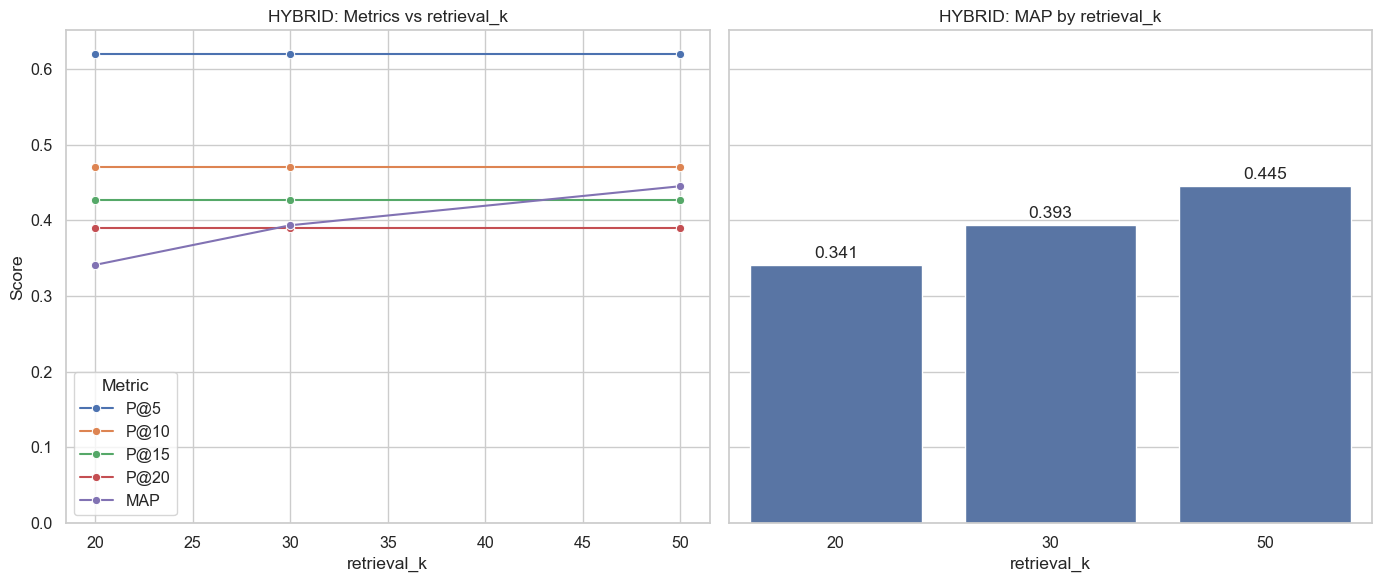

IR_DIR = c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025
Outputs: ['c:\\Users\\perik\\Downloads\\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\\IR2025\\results_hybrid_20.txt', 'c:\\Users\\perik\\Downloads\\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\\IR2025\\results_hybrid_30.txt', 'c:\\Users\\perik\\Downloads\\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\\IR2025\\results_hybrid_50.txt']
Summary: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\trec_eval_hybrid_summary.txt


In [14]:
def visualize_metrics(df):
    metrics = ["P@5", "P@10", "P@15", "P@20", "MAP"]
    df_melt = df.melt(id_vars="retrieval_k", value_vars=metrics,
                      var_name="Metric", value_name="Score")

    sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    sns.lineplot(data=df_melt, x="retrieval_k", y="Score", hue="Metric", marker="o", ax=ax1)
    ax1.set_title("HYBRID: Metrics vs retrieval_k")
    ax1.set_xlabel("retrieval_k")
    ax1.set_ylabel("Score")

    map_only = df_melt[df_melt["Metric"] == "MAP"]
    barplot = sns.barplot(data=map_only, x="retrieval_k", y="Score", ax=ax2)
    ax2.set_title("HYBRID: MAP by retrieval_k")

    for p in barplot.patches:
        value = f"{p.get_height():.3f}"
        ax2.annotate(value, (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")

    plt.tight_layout()
    plt.show()

visualize_metrics(df_hybrid)

print("IR_DIR =", IR_DIR)
print("Outputs:", [str(IR_DIR / f"results_hybrid_{k}.txt") for k in RESULT_KS])
print("Summary:", IR_DIR / "trec_eval_hybrid_summary.txt")